In [1]:
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
import requests
import pickle
import random
from scipy.interpolate import griddata
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
# pip install --upgrade pypa

In [2]:
from age_pension import calculate_pension_income
from CHSP_GRandF import GRandF_CHSP
from HCP_GRandF import GRandF_HCP
from RC_GRandF import GRandF_RC
from comInterp import compress_interp
from FIstatus import I_status, F_status
from DeltaW import Delta_W_status
from updown_prep import derivatives_tp1, direct2EI, Hstate2Cf, reVC, Compare35

In [3]:
with open('Dict_35', 'rb') as file:
    Dict_35 = pickle.load(file)
with open('Dict_12', 'rb') as file:
    Dict_12 = pickle.load(file)

with open('National_Transit.pkl', 'rb') as file:
    National_Transit = pickle.load(file)
    
with open('ME_grid_H.pkl', 'rb') as file:
    ME_grid_H = pickle.load(file)

with open('ME_grid_ir.pkl', 'rb') as file:
    ME_grid_ir = pickle.load(file)

with open('ME_grid_cpi.pkl', 'rb') as file:
    ME_grid_cpi = pickle.load(file)

ME_grid_cpi[0] = [1]
ME_grid_H[0] = [1]

In [4]:
# This is the case when the total initial wealth = 560000 
def return_calib_var(alpha):
    Leasing = 1
    W =  560000 
    H = W * alpha/(alpha+1)
    tau1_arr = np.full(41, 1/6)
    tau2_HCP4 = np.full(41, 3/4)
    tau2_RC = np.full(41, 1/24)
    return H, W/(1+alpha), tau1_arr, tau2_HCP4, tau2_RC, Leasing


In [5]:
def find_best_alpha():
    Dict_Value_initial = {}
    for i in range(25):
        Interpolate_initial = Dict_12[i]['WV1'][1][0]
        alpha = alphas[i]
        H_ini, W_ini, tau1_arr, tau2_HCP4_arr, tau2_RC_arr, Leasing = return_calib_var(alpha)
        Value_initial = Interpolate_initial(W_ini)
        Dict_Value_initial[i] = Value_initial
    key_with_highest_value  = max(Dict_Value_initial, key=lambda k: Dict_Value_initial[k])
    alpha_best= alphas[key_with_highest_value]
    return alpha_best, key_with_highest_value

In [6]:
ratios = np.linspace(0.05, 0.95, 25)  # Create 41 points from 0 to 1 exclusive
alphas = ratios / (1 - ratios)  # Solve alpha / (1 + alpha) = ratio for alpha
alpha_index_12 = find_best_alpha()[1]
H_ini, W_ini, tau1_arr, tau2_HCP4_arr, tau2_RC_arr, Leasing = return_calib_var(alphas[alpha_index_12])
estimate_prop = H_ini/1200000
alpha_index_35 = np.argmin(np.abs(ratios - estimate_prop))

In [7]:
alpha_index_12

22

In [8]:
alpha_index_35

10

In [9]:
def generate_EI_sequence(length):
    sequence = [0]
    for _ in range(1, length):
        # Add either 0 or 1 to the last element
        next_element = sequence[-1] + random.choice([0, 1])
        sequence.append(next_element)
    return sequence

def generate_Health_sequence_DS(Initial_HState): 
    HS_traj =[Initial_HState-1, Initial_HState-1]
    for t in range(1,40):
        new_state = np.random.choice(range(4), p = National_Transit[t][HS_traj[-1]])
        HS_traj.append(new_state)
        if  HS_traj[-1] == 3:
            break
            
    return [x + 1 for x in HS_traj[:-1]]

In [10]:
Dict_interpolated_C_= {} 

Dict_interpolated_C_ = {}
Dict_interpolated_C_[1] =  Dict_12[alpha_index_12]['WC1']
Dict_interpolated_C_[2] =  Dict_12[alpha_index_12]['WC2']
Dict_interpolated_C_[3] =  Dict_35[alpha_index_35]['WC3']
Dict_interpolated_C_[5] =  Dict_35[alpha_index_35]['WC5']

In [11]:
def wealth_law(EI_t, W_t, C_t, alpha, t, Hadded, Hstate):
    H_ini, W_ini, tau1_arr, tau2_HCP4_arr, tau2_RC_arr, Leasing = return_calib_var(alpha)
    r_t = ME_grid_ir[t][EI_t]/100
    cpi_t = ME_grid_cpi[t][EI_t]
    H_t = H_ini * ME_grid_H[t][EI_t] / cpi_t
    I_t = I_status(W_t, H_t, Hstate)
    F_t = F_status(W_t, H_t, Hstate)
    W_tp1 = (W_t - C_t + I_t - F_t)*(1 + r_t) + H_t*Hadded
    return W_tp1

In [12]:
def generate_CWtp1(t, W_t, Hstate_t, EI_tm1, EI_t): # Retained home equity size is detemined by Hstate_ini
    alpha = alphas[alpha_index_12]
    C_interpolated_ = Dict_interpolated_C_[Hstate_t][t][EI_tm1]
    C_output = C_interpolated_(W_t)
    W_output = wealth_law(EI_t, W_t, C_output, alpha, t, 0, Hstate_t)
    return C_output, W_output

In [13]:
def find_avg(arrays, state_arrays, state_limit):
    max_length = max(len(arr) for arr in arrays)
    sums = [0] * max_length
    counts = [0] * max_length
    arr_index = 0 
    for arr in arrays:
        H_arr = state_arrays[arr_index]
    # Sum the values and count the occurrences for each position
        for i in range(len(arr)):
            if H_arr[i] == state_limit:
                if arr[i] is not None: 
                    sums[i] += arr[i]
                    counts[i] += 1
        arr_index += 1
    arr_avg = []
    for i in range(max_length):
        if counts[i] == 0:
            averages = 0
        if counts[i] != 0:
            averages = sums[i] / counts[i]
        arr_avg.append(averages)
    return arr_avg

def find_final(arrays):
    max_length = max(len(arr) for arr in arrays)
    # Initialize a list to hold the sums and a list for counting the elements in each position
    sums = [0] * max_length
    counts = [0] * max_length
    # Sum the values and count the occurrences for each position
    for arr in arrays:
        for i in range(len(arr)):
            if arr[i] is not None: 
                sums[i] += arr[i]
                counts[i] += 1
    # Calculate the average for each position
    averages = [sums[i] / counts[i] for i in range(max_length)]
    return averages


In [14]:
def sim_traj(sim_times):
    Dict_arr_W = {}
    Dict_arr_C = {}
    Dict_arr_HS= {}
    Dict_arr_35 = {}
    H_ini, W_ini, tau1_arr, tau2_HCP4_arr, tau2_RC_arr, Leasing = return_calib_var(alphas[alpha_index_12])
    for i in range(sim_times):
        arr_W_t = [W_ini]
        arr_C_t = [ ]
        arr_35_t = [ ]
        arr_HState = generate_Health_sequence_DS(1)
        H_len  = len(arr_HState)
        arr_EI = generate_EI_sequence(H_len)
        for t in range(1,H_len):
            W_t = arr_W_t[-1]
            Hstate_tm1 = arr_HState[t-1]
            EI_tm1     = arr_EI[t-1]
            Hstate_t   = arr_HState[t]
            EI_t       = arr_EI[t]
            r_t = ME_grid_ir[t][EI_t]/100
            cpi_t = ME_grid_cpi[t][EI_t]
            H_t = H_ini * ME_grid_H[t][EI_t] / cpi_t
            C_t, W_tp1 = generate_CWtp1(t, W_t, Hstate_t, EI_tm1, EI_t)
            V3 = Dict_35[alpha_index_35]['WV3'][t][EI_tm1](W_tp1 - Delta_W_status(W_tp1, H_t, 3, tau1_arr[t], tau2_HCP4_arr[t], tau2_RC_arr[t]))
            V5 = Dict_35[alpha_index_35]['WV5'][t][EI_tm1](W_tp1 - Delta_W_status(W_tp1, H_t, 5, tau1_arr[t], tau2_HCP4_arr[t], tau2_RC_arr[t]))
            selected = None
            if Hstate_t < 3: 
                if V3 <= V5:
                    selected = 1
                if V3 > V5:
                    selected = 0
            arr_35_t.append(selected)
            arr_W_t.append(W_tp1)
            arr_C_t.append(C_t)
        Dict_arr_W[i] = arr_W_t[:-1]
        Dict_arr_C[i] = arr_C_t
        Dict_arr_HS[i] = arr_HState[1: ]
        Dict_arr_35[i] = arr_35_t
        
    return Dict_arr_W, Dict_arr_C, Dict_arr_HS, Dict_arr_35

In [15]:
Dict_arr_W_, Dict_arr_C_, Dict_arr_HS_,  Dict_arr_S_ = sim_traj(sim_times = 20000)

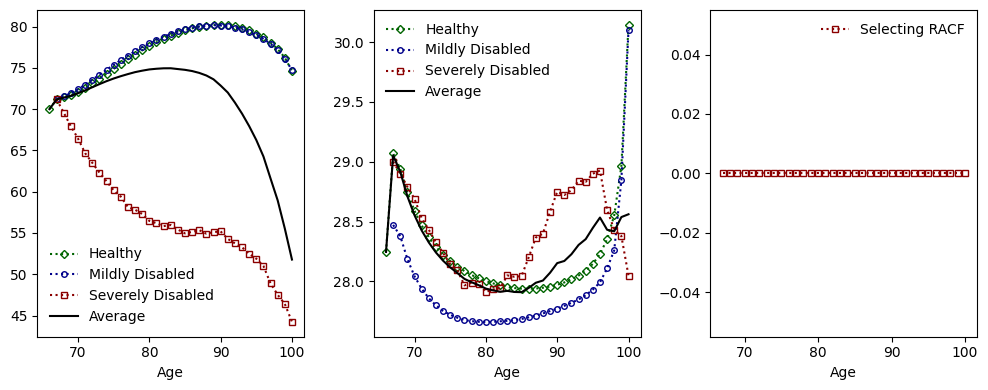

In [16]:
W1 = find_avg(list(Dict_arr_W_.values()), list(Dict_arr_HS_.values()), 1)[0:35]
W2 = find_avg(list(Dict_arr_W_.values()), list(Dict_arr_HS_.values()), 2)[0:35]
W3 = find_avg(list(Dict_arr_W_.values()), list(Dict_arr_HS_.values()), 3)[0:35]
W_all =  find_final(list(Dict_arr_W_.values()))[0:35]

C1 = find_avg(list(Dict_arr_C_.values()), list(Dict_arr_HS_.values()), 1)[0:35]
C2 = find_avg(list(Dict_arr_C_.values()), list(Dict_arr_HS_.values()), 2)[0:35]
C3 = find_avg(list(Dict_arr_C_.values()), list(Dict_arr_HS_.values()), 3)[0:35]
C_all =  find_final(list(Dict_arr_C_.values()))[0:35]


S1 = find_avg(list(Dict_arr_S_.values()), list(Dict_arr_HS_.values()), 1)[0:35]
S2 = find_avg(list(Dict_arr_S_.values()), list(Dict_arr_HS_.values()), 2)[0:35]
S_all =  find_final(list(Dict_arr_S_.values()))[0:35]


fig, axes = plt.subplots(1, 3, figsize=(10,4))

colors = ['darkgreen', 'darkblue', 'darkred', 'black']
line_styles = [':', ':', ':']  # solid and dashed lines
point_types = ['D', 'o','s']  # circle and square markers

# Plot data with academic styles
axes[0].plot(range(66, 101), np.array(W1)/1000, color=colors[0], linestyle=line_styles[0], marker=point_types[0],markerfacecolor='none', markersize=4, label='Healthy')
axes[0].plot(range(67, 101), np.array(W2)[1:]/1000, color=colors[1], linestyle=line_styles[1], marker=point_types[1],markerfacecolor='none', markersize=4,label='Mildly Disabled')
axes[0].plot(range(67, 101), np.array(W3)[1:]/1000, color=colors[2], linestyle=line_styles[2], marker=point_types[2],markerfacecolor='none', markersize=4,label='Severely Disabled')
axes[0].plot(range(66, 101), np.array(W_all)/1000, color=colors[3], label='Average')

# Plot data with academic styles
axes[1].plot(range(66, 101), np.array(C1)/1000, color=colors[0], linestyle=line_styles[0], marker=point_types[0],markerfacecolor='none', markersize=4, label='Healthy')
axes[1].plot(range(67, 101), np.array(C2)[1:]/1000, color=colors[1], linestyle=line_styles[1], marker=point_types[1],markerfacecolor='none', markersize=4,label='Mildly Disabled')
axes[1].plot(range(67, 101), np.array(C3)[1:]/1000, color=colors[2], linestyle=line_styles[2], marker=point_types[2],markerfacecolor='none', markersize=4,label='Severely Disabled')
axes[1].plot(range(66, 101), np.array(C_all)/1000, color=colors[3], label='Average')


axes[2].plot(range(67, 101), np.array(S_all)[1:], color=colors[2], linestyle=line_styles[2],  marker=point_types[2] ,markerfacecolor='none', markersize=4, label='Selecting RACF')




for ax in axes:
    ax.set_xlabel("Age")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [17]:
Dict_W_Baseline = {}
Dict_W_Baseline[1] = np.array(W1)/1000
Dict_W_Baseline[2] = np.array(W2)[1:]/1000
Dict_W_Baseline[3] = np.array(W3)[1:]/1000
Dict_W_Baseline[123] = np.array(W_all)/1000
with open('Dict_W_Baseline.pkl', 'wb') as file:
    pickle.dump(Dict_W_Baseline, file)
    
Dict_C_Baseline = {}
Dict_C_Baseline[1] = np.array(C1)/1000
Dict_C_Baseline[2] = np.array(C2)[1:]/1000
Dict_C_Baseline[3] = np.array(C3)[1:]/1000
Dict_C_Baseline[123] = np.array(C_all)/1000
with open('Dict_C_Baseline.pkl', 'wb') as file:
    pickle.dump(Dict_C_Baseline, file)


Dict_S_Baseline = {}
Dict_S_Baseline[123] = np.array(S_all)[1:]
with open('Dict_S_Baseline.pkl', 'wb') as file:
    pickle.dump(Dict_S_Baseline, file)